### Load Data & Preprocessing

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [144]:
# Read pull + processed data (8 genres/classes)
df = pd.read_csv("CSV_FOR_MODEL.csv")
print(f"Loaded: {len(df)} rows x {len(df.columns)} columns")
print(df["primary_genre"].value_counts())

Loaded: 20019 rows x 54 columns
primary_genre
Drama        3955
Thriller     2973
Comedy       2826
Action       2678
Romance      2561
Horror       2264
Adventure    1590
Family       1172
Name: count, dtype: int64


In [145]:
# ─────────────────────────────────────────────────────────────
# GENRE MERGING: 8 → 5 classes
# Thriller + Adventure → Action: consistently confused in v2/v3
# Family → Comedy: consistently confused in v3, smallest class,
#  similar female representation profile to Comedy
# ─────────────────────────────────────────────────────────────
GENRE_MERGE = {
    "Thriller":  "Action",
    "Adventure": "Action",
    "Family":    "Comedy",
}

df["genre_5class"] = df["primary_genre"].replace(GENRE_MERGE)

print("Genre distribution after merging to 5 classes:")
print(df["genre_5class"].value_counts())

Genre distribution after merging to 5 classes:
genre_5class
Action     7241
Comedy     3998
Drama      3955
Romance    2561
Horror     2264
Name: count, dtype: int64


In [146]:
# Filter lead gender so it only considers known male and female
v4_df = df[df["lead_gender"].isin([1.0, 2.0])]
# Drop columns from previous versions
v4_df = v4_df.drop(columns = ['representation_tier', 'genre_crime',
       'genre_action', 'genre_documentary', 'genre_fantasy', 'genre_drama',
       'genre_tv_movie', 'genre_family', 'genre_animation', 'genre_music',
       'genre_thriller', 'genre_history', 'genre_adventure',
       'genre_science_fiction', 'genre_mystery', 'genre_horror', 'genre_war',
       'genre_romance', 'genre_comedy', 'genre_western', 'primary_genre'])
print(v4_df.info())
print(v4_df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 19445 entries, 0 to 20018
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tmdb_id               19445 non-null  int64  
 1   title                 19445 non-null  object 
 2   release_date          19445 non-null  object 
 3   release_year          19445 non-null  int64  
 4   decade                19445 non-null  int64  
 5   overview              19445 non-null  object 
 6   popularity            19445 non-null  float64
 7   vote_average          19445 non-null  float64
 8   vote_count            19445 non-null  int64  
 9   original_language     19445 non-null  object 
 10  genre_names           19445 non-null  object 
 11  primary_country       19445 non-null  object 
 12  primary_company       19445 non-null  object 
 13  language_count        19445 non-null  int64  
 14  lead_gender           19445 non-null  float64
 15  lead_actor_name       19

### Genre Distribution Plot

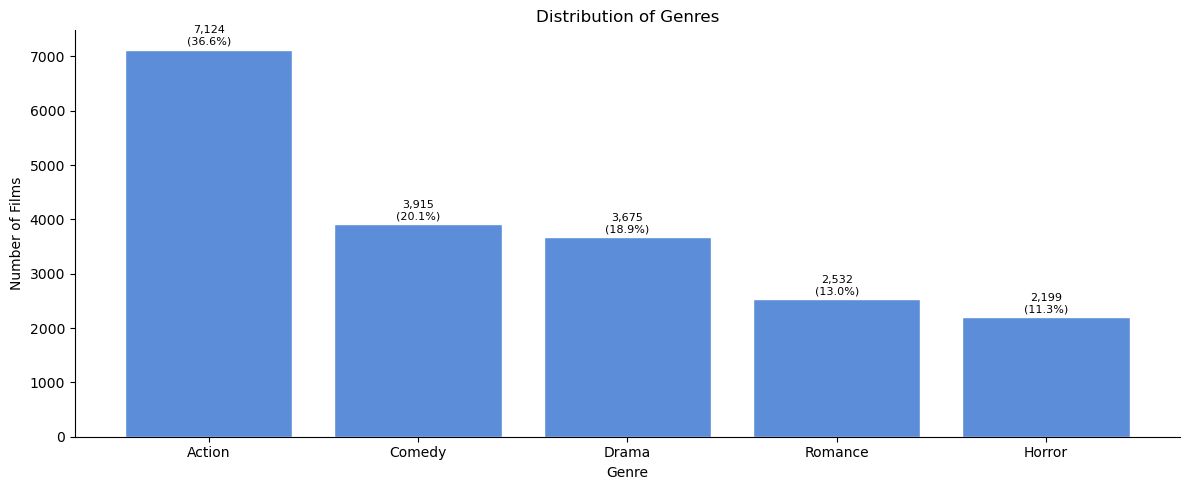

In [148]:
fig, ax = plt.subplots(figsize=(12, 5))
counts = v4_df['genre_5class'].value_counts()
colors = ['#5b8dd9'] * len(counts)

bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white')

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count:,}\n({100*count/len(v4_df):.1f}%)',
            ha='center', va='bottom', fontsize=8)

ax.set_title('Distribution of Genres')
ax.set_xlabel('Genre')
ax.set_ylabel('Number of Films')
sns.despine()
plt.tight_layout()
plt.show()

### Genre Distribution by Cast/Crew Category

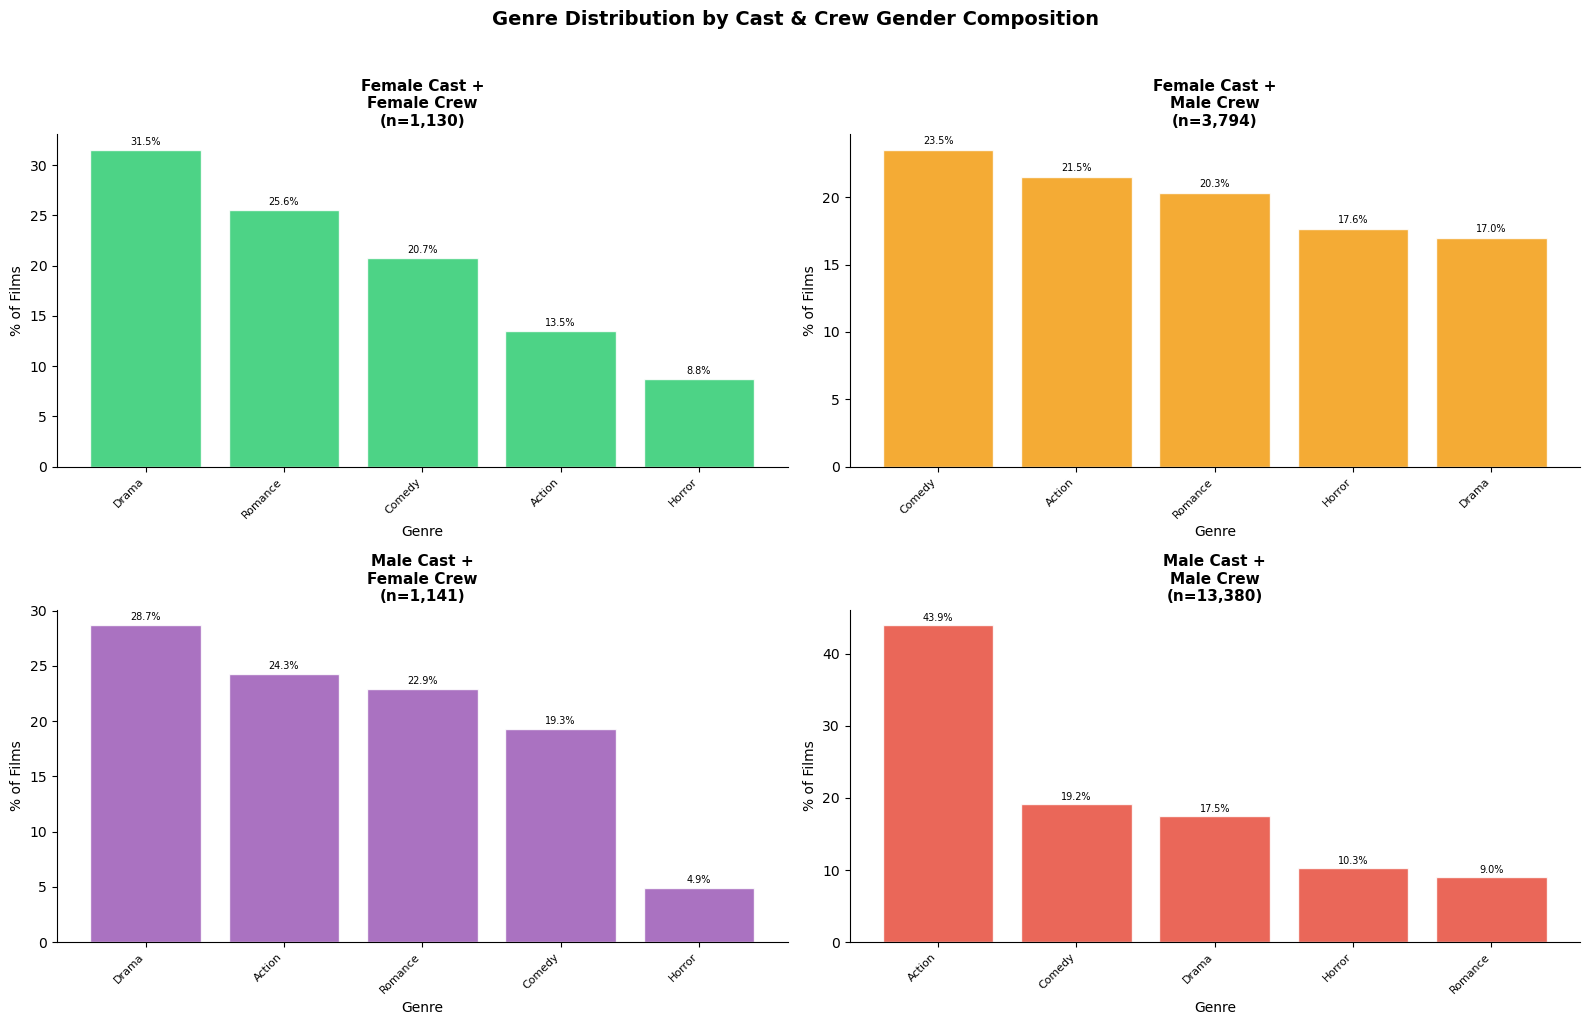

Category distribution:
  Male Cast +
Male Crew              : 13380 (68.8%)
  Female Cast +
Male Crew            :  3794 (19.5%)
  Male Cast +
Female Crew            :  1141 (5.9%)
  Female Cast +
Female Crew          :  1130 (5.8%)


In [150]:
# Recoding the director_gender from TMDb encoding (1=female, 2=male) to binary (1=female, 0=male)
v4_df["director_female"] = v4_df["director_gender"].map({1.0: 1, 2.0: 0})
v4_df["pct_female_crew"] = v4_df[["director_female", "pct_female_writers", "pct_female_producers"]].mean(axis=1)

# Threshold of 50% defines "majority" for both cast and crew
THRESHOLD = 0.5

def assign_category(row):
    female_cast = row["pct_female_cast"] >= THRESHOLD
    female_crew = row["pct_female_crew"] >= THRESHOLD
    if female_cast and female_crew:
        return "Female Cast +\nFemale Crew"
    elif female_cast and not female_crew:
        return "Female Cast +\nMale Crew"
    elif not female_cast and female_crew:
        return "Male Cast +\nFemale Crew"
    else:
        return "Male Cast +\nMale Crew"

v4_df["cast_crew_category"] = v4_df.apply(assign_category, axis=1)

categories = [
    "Female Cast +\nFemale Crew",
    "Female Cast +\nMale Crew",
    "Male Cast +\nFemale Crew",
    "Male Cast +\nMale Crew"
]

# Color coding: green = most female representation, red = least
colors = ["#2ecc71", "#f39c12", "#9b59b6", "#e74c3c"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=False)
axes = axes.flatten()

for ax, category, color in zip(axes, categories, colors):
    cat_df = v4_df[v4_df["cast_crew_category"] == category]
    genre_counts = cat_df["genre_5class"].value_counts()

    # Use proportions instead of raw counts so genres are comparable across
    # categories with very different sample sizes 
    genre_pct = (genre_counts / len(cat_df) * 100).sort_values(ascending=False)

    bars = ax.bar(genre_pct.index, genre_pct.values,
                  color=color, edgecolor="white", alpha=0.85)

    for bar, pct in zip(bars, genre_pct.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=7)

    # Include sample size N in each title 
    ax.set_title(f"{category}\n(n={len(cat_df):,})", fontweight="bold", fontsize=11)
    ax.set_xlabel("Genre")
    ax.set_ylabel("% of Films")
    ax.set_xticks(range(len(genre_pct)))
    ax.set_xticklabels(genre_pct.index, rotation=45, ha="right", fontsize=8)
    sns.despine()

plt.suptitle("Genre Distribution by Cast & Crew Gender Composition",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Print category breakdown to look at gender imbalance
print("Category distribution:")
cat_counts = v4_df["cast_crew_category"].value_counts()
for cat, count in cat_counts.items():
    print(f"  {cat:35s}: {count:5d} ({100*count/len(v4_df):.1f}%)")

### Director Gender Distribution Across Genres

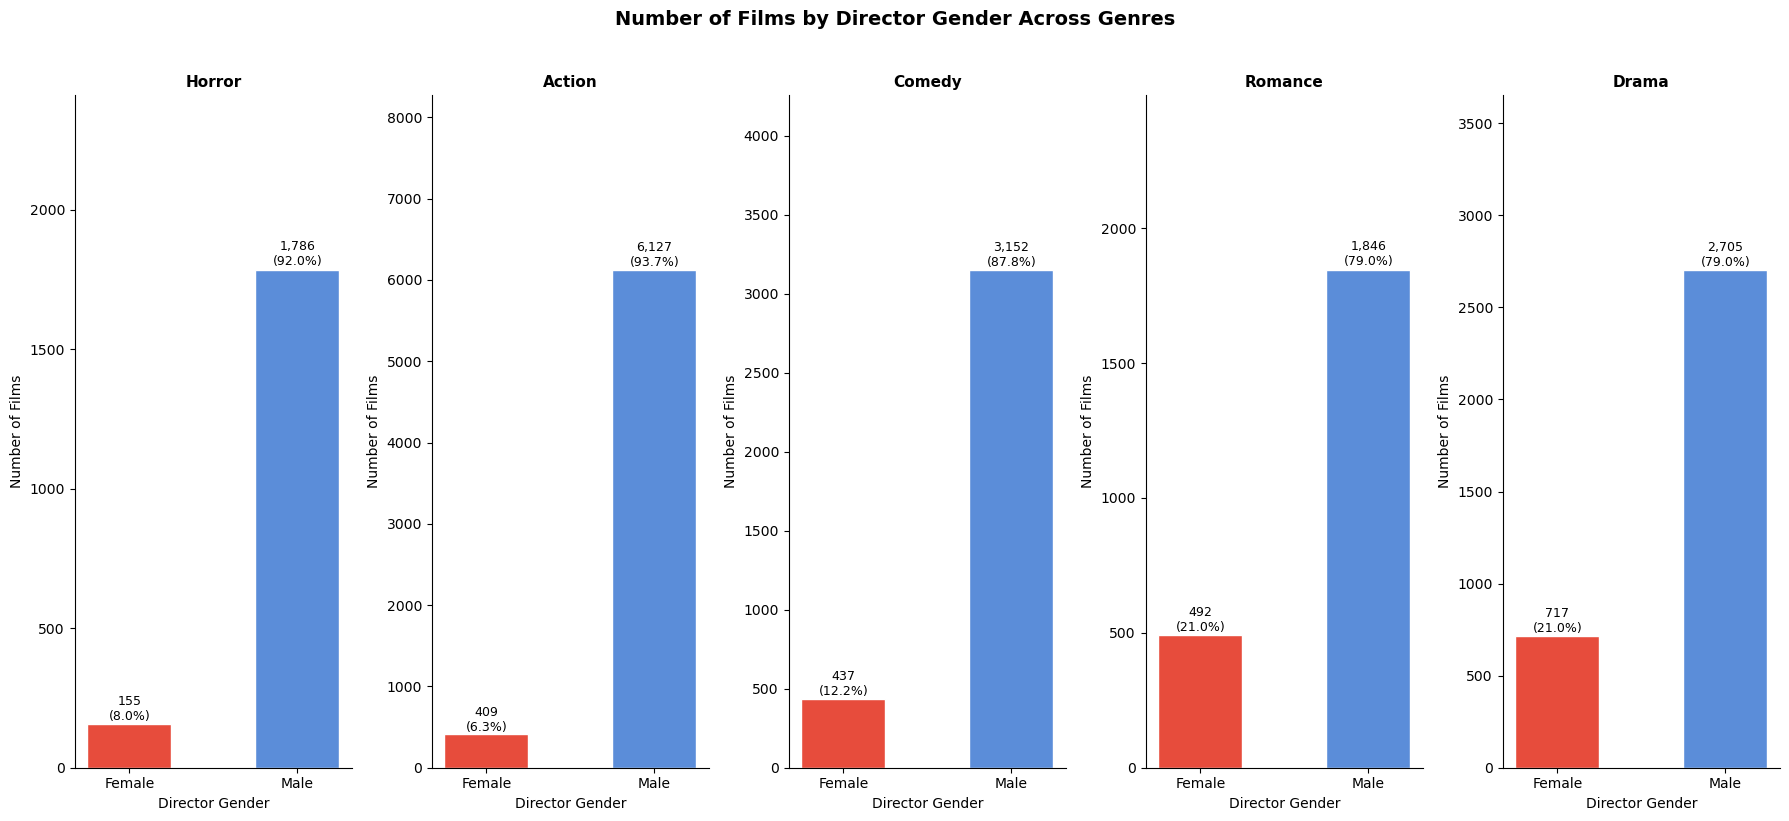

In [152]:
# Filter to known genders only (male and female)
gender_df = v4_df[v4_df["director_gender"].isin([1.0, 2.0])].copy()
gender_df["director_gender_label"] = gender_df["director_gender"].map({1.0: "Female", 2.0: "Male"})

genres = list(v4_df["genre_5class"].unique())
colors = ["#e74c3c", "#5b8dd9"]  # red = female, blue = male

fig, axes = plt.subplots(1, 5, figsize=(18, 8), sharey=False)
axes = axes.flatten()

for ax, genre in zip(axes, genres):
    genre_df = gender_df[gender_df["genre_5class"] == genre]
    counts = genre_df["director_gender_label"].value_counts().reindex(["Female", "Male"], fill_value=0)

    bars = ax.bar(counts.index, counts.values,
                  color=colors, edgecolor="white", width=0.5)

    for bar, count in zip(bars, counts.values):
        pct = 100 * count / counts.sum() if counts.sum() > 0 else 0
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f"{count:,}\n({pct:.1f}%)",
                ha="center", va="bottom", fontsize=9)

    ax.set_title(genre, fontweight="bold", fontsize=11)
    ax.set_xlabel("Director Gender")
    ax.set_ylabel("Number of Films")
    ax.set_ylim(0, counts.max() * 1.35)
    sns.despine()

plt.suptitle("Number of Films by Director Gender Across Genres",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Female Representation in Creative Roles Over Time

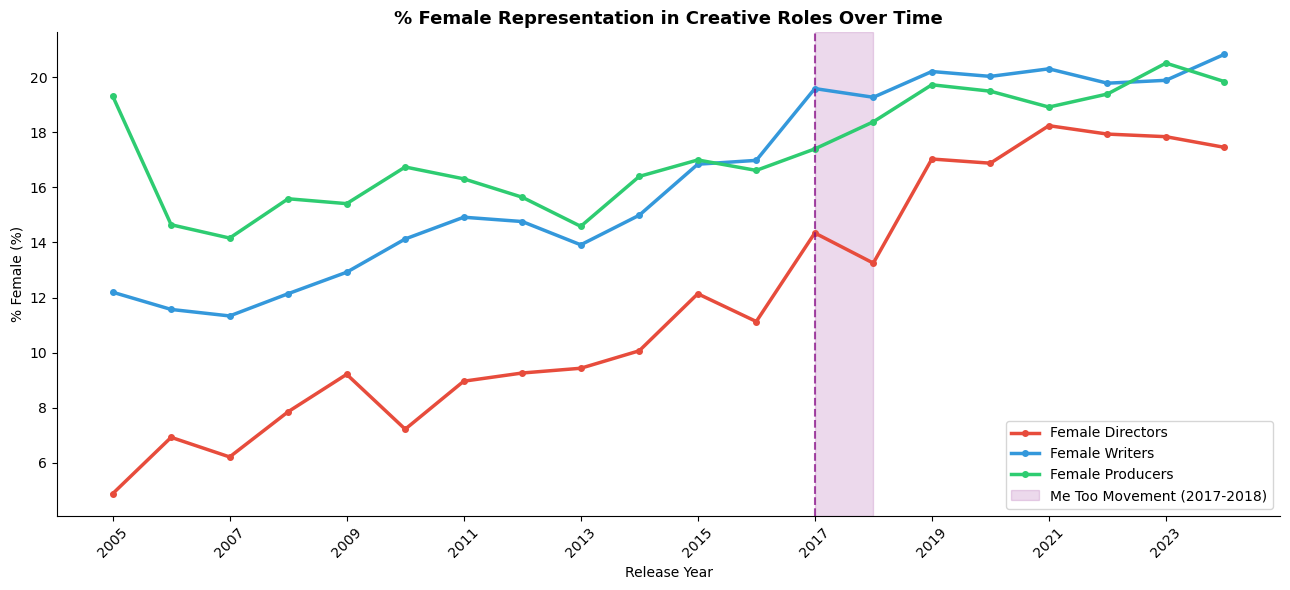

In [154]:
# Filter to known director genders only
time_df = v4_df[v4_df["director_gender"].isin([1.0, 2.0])].copy()

# Recode director to binary
time_df["director_female"] = time_df["director_gender"].map({1.0: 1, 2.0: 0})

# Aggregate by year
yearly = time_df.groupby("release_year").agg(
    pct_female_director  = ("director_female",      "mean"),
    pct_female_writers   = ("pct_female_writers",   "mean"),
    pct_female_producers = ("pct_female_producers", "mean"),
).reset_index()

yearly = yearly[(yearly["release_year"] >= 2005) & (yearly["release_year"] <= 2024)]

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(yearly["release_year"], yearly["pct_female_director"]  * 100,
        label="Female Directors",  color="#e74c3c", linewidth=2.5, marker="o", markersize=4)
ax.plot(yearly["release_year"], yearly["pct_female_writers"]   * 100,
        label="Female Writers",    color="#3498db", linewidth=2.5, marker="o", markersize=4)
ax.plot(yearly["release_year"], yearly["pct_female_producers"] * 100,
        label="Female Producers",  color="#2ecc71", linewidth=2.5, marker="o", markersize=4)

# Me Too movement vertical line
ax.axvspan(2017, 2018, color="purple", alpha=0.15, label="Me Too Movement (2017-2018)")
ax.axvline(2017, color="purple", linestyle="--", linewidth=1.5, alpha=0.7)

ax.set_title("% Female Representation in Creative Roles Over Time",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Release Year")
ax.set_ylabel("% Female (%)")
ax.legend(fontsize=10)
ax.set_xticks(range(2005, 2025, 2))
ax.set_xticklabels(range(2005, 2025, 2), rotation=45)
sns.despine()
plt.tight_layout()
plt.show()

### Gender Composition of Creative Roles Over Time

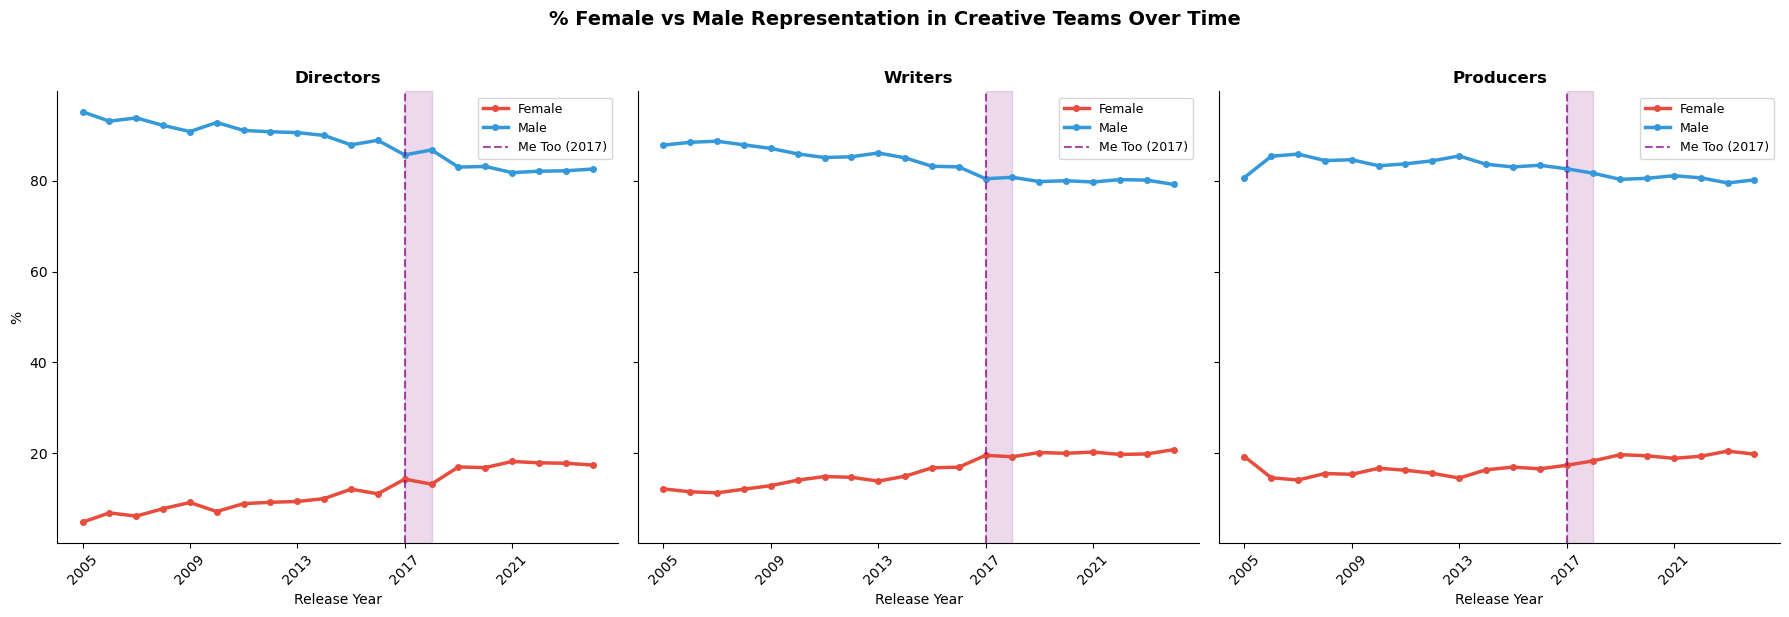

In [156]:
# Compute male percentages as inverse
yearly["pct_male_director"]  = 1 - yearly["pct_female_director"]
yearly["pct_male_writers"]   = 1 - yearly["pct_female_writers"]
yearly["pct_male_producers"] = 1 - yearly["pct_female_producers"]

# Filter to 2006-2024
yearly = yearly[(yearly["release_year"] >= 2005) & (yearly["release_year"] <= 2024)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

roles = [
    ("Directors",  "pct_female_director",  "pct_male_director"),
    ("Writers",    "pct_female_writers",   "pct_male_writers"),
    ("Producers",  "pct_female_producers", "pct_male_producers"),
]

for ax, (role, female_col, male_col) in zip(axes, roles):
    ax.plot(yearly["release_year"], yearly[female_col] * 100,
            label="Female", color="#e74c3c", linewidth=2.5, marker="o", markersize=4)
    ax.plot(yearly["release_year"], yearly[male_col] * 100,
            label="Male", color="#3498db", linewidth=2.5, marker="o", markersize=4)

    # Me Too marker
    ax.axvspan(2017, 2018, color="purple", alpha=0.15)
    ax.axvline(2017, color="purple", linestyle="--", linewidth=1.5, alpha=0.7,
               label="Me Too (2017)")

    ax.set_title(role, fontweight="bold", fontsize=12)
    ax.set_xlabel("Release Year")
    ax.set_ylabel("%" if ax == axes[0] else "")
    ax.set_xticks(range(2005, 2025, 4))
    ax.set_xticklabels(range(2005, 2025, 4), rotation=45)
    ax.legend(fontsize=9)
    sns.despine()

plt.suptitle("% Female vs Male Representation in Creative Teams Over Time",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Female Representation in Film Roles Across Genre

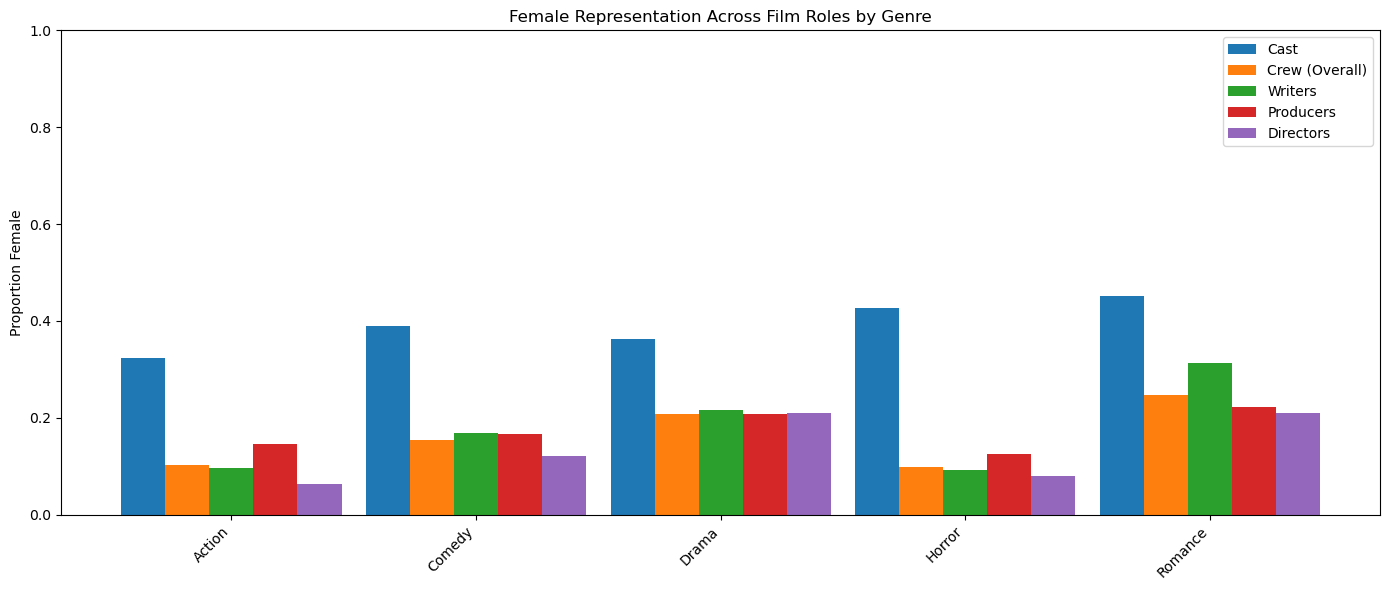

In [158]:
roles = {
    "Cast": "pct_female_cast",
    "Crew (Overall)": "pct_female_crew",
    "Writers": "pct_female_writers",
    "Producers": "pct_female_producers",
    "Directors": "director_female" 
}

# Group by genre
genre_stats = v4_df.groupby("genre_5class")[list(roles.values())].mean()

fig, ax = plt.subplots(figsize=(14, 6))

x = range(len(genre_stats))
width = 0.18

for i, (label, col) in enumerate(roles.items()):
    ax.bar(
        [xi + i * width for xi in x],
        genre_stats[col],
        width=width,
        label=label
    )

ax.set_xticks([xi + width * 2 for xi in x])
ax.set_xticklabels(genre_stats.index, rotation=45, ha="right")

ax.set_ylabel("Proportion Female")
ax.set_title("Female Representation Across Film Roles by Genre")
ax.set_ylim(0, 1)

ax.legend()
plt.tight_layout()
plt.show()